# 🧪 Lab 01: Transfer Learning Fundamentals

We've built neural networks from scratch in previous labs. While that's a valuable skill, our custom models often don't perform as well as we'd like.  

What if we could use a model that's already been trained on millions of images?  
👉 That's exactly what **Transfer Learning** allows us to do!

---

## 🎯 Objectives

- Understand what **Transfer Learning** is and why it's powerful  
- Learn where to find **pretrained models**  
- Download and explore a pretrained **EfficientNet_B0 model**  
- Understand model architecture:
  - Features
  - AvgPool
  - Classifier  
- Learn to **freeze base layers** and modify the classifier head  
- Use `torchinfo.summary()` to inspect model structure  

---

## 📌 Prerequisites

Before starting this lab, you should have:

- ✅ Completed **Computer Vision labs**
  - Understanding of CNNs  
  - Knowledge of Conv2d  
  - Experience with training loops  

- ✅ Basic knowledge of:
  - PyTorch  
  - Neural Networks  

## 📘 Project Overview

This is a **2-lab series on Transfer Learning with PyTorch** where we solve an image classification problem using a pretrained model.  

Instead of building a CNN from scratch, we'll leverage a model that's already learned powerful image representations from millions of images.

---

### 🔬 Lab Breakdown

#### 🧪 Lab 01
In this lab, we focus on understanding **transfer learning concepts** and setting up a pretrained **EfficientNet_B0 model**.

We will:
- Download the pretrained model  
- Explore its architecture  
- Freeze the base layers  
- Modify the classifier for our custom task  

---

#### 🧪 Lab 02
In the next lab, we will:
- Train the model on our **pizza / steak / sushi dataset**  
- Evaluate performance  
- Make predictions on new images  

---

## 📊 Lab Overview

In this lab, we will:

- Download a pretrained **EfficientNet_B0** model from `torchvision.models`  
- Understand its architecture  
- Freeze the **feature extraction layers**  
- Customize the **classifier head**  

🎯 Goal: Solve a **3-class food classification problem**
- 🍕 Pizza  
- 🥩 Steak  
- 🍣 Sushi  

## 🖼️ What is ImageNet?

**ImageNet** is a massive image database that has become the benchmark for computer vision research.

---

### 📊 Key Facts

- 📦 **Size:** Over 14 million labeled images  
- 🏷️ **Categories:** 1000+ object classes  
  - Animals 🐶  
  - Vehicles 🚗  
  - Food 🍔  
  - Everyday objects 🪑  

- 🎯 **Purpose:**  
  Used for training and evaluating **image classification models**


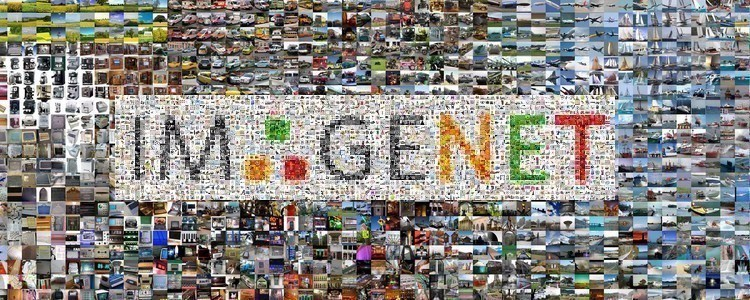

Most pretrained models you'll encounter (including EfficientNet) were trained on ImageNet. When we say a model was "pretrained on ImageNet," it means the model learned to recognize patterns from millions of diverse images before we use it for our specific task.

This is why transfer learning works so well — a model trained on ImageNet has already learned general visual features (edges, textures, shapes, objects) that are useful for almost any image classification problem.

এই কথাটা **transfer learning-এর আসল power** বুঝায়—চলো সহজভাবে ভেঙে দেখি 👇

---

## 🔷 “Pretrained on ImageNet” মানে কী?

যখন বলি একটা model **ImageNet-এ pretrained**, তখন এর মানে:

👉 Model আগে থেকেই **millions of images** দেখে শিখেছে
👉 1000 ধরনের object চিনতে পারে

অর্থাৎ, model already অনেক visual knowledge gain করে ফেলেছে।

---

## 🔷 Model আসলে কী শিখে?

ImageNet-এ train করার সময় model ধাপে ধাপে শিখে:

1️⃣ **Low-level features**

* edges (কিনারা)
* colors
* gradients

2️⃣ **Mid-level features**

* textures
* patterns

3️⃣ **High-level features**

* shapes
* object parts (eye, wheel, etc.)

---

## 🔷 কেন এটা এত powerful?

👉 এই featuresগুলো **generic (সাধারণ)**
মানে এগুলো প্রায় সব image problem-এ কাজে লাগে

উদাহরণ:

* edge detection → সব image-এ দরকার
* shape detection → সব object-এ দরকার

---

## 🔷 তাই Transfer Learning কাজ করে 🔥

যখন তুমি pretrained model use করো:

* তোমাকে আবার edge/shape শেখাতে হয় না
* model already smart
* তুমি শুধু নতুন task (e.g., flower classification) শেখাও




**What is Transfer Learning?**

Transfer learning allows us to take the patterns (also called weights) another model has learned from another problem and use them for our own problem.

Transfer Learning হলো এমন একটি technique যেখানে আমরা একটি model-এর আগে থেকে শেখা knowledge (weights/patterns) ব্যবহার করি নতুন problem solve করার জন্য।

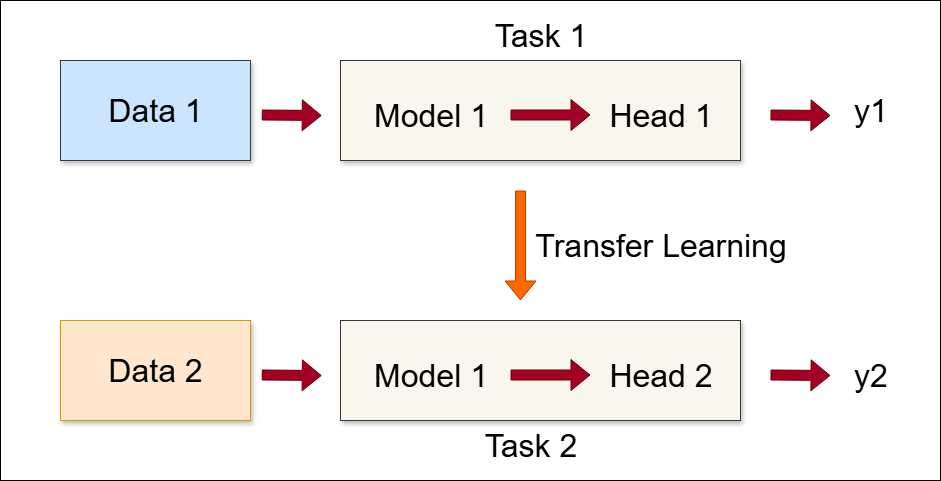

In the diagram above, Task 1 shows a model trained on a large dataset (Data 1, like ImageNet). The model learns to extract features and uses Head 1 to classify images into its original categories (y1 = 1000 classes).

With transfer learning, we take this trained model and apply it to a completely different task. In Task 2, we use the same Model 1 (keeping all its learned patterns), but we replace Head 1 with a new Head 2 that's designed for our specific problem. Now the model can classify our new data (Data 2) into our categories (y2 = 3 classes like pizza, steak, sushi).

The key insight is that Model 1 stays the same — it has already learned useful features like edges, textures, and shapes from millions of images. We only change the Head (the final classification layer) to match our specific problem.

এই diagram-এর explanationটা খুব গুরুত্বপূর্ণ—চলো একদম clearভাবে বুঝি 👇

---

## 🔷 Task 1 (Original Training)

* Model train করা হয়েছে বড় dataset দিয়ে (যেমন: ImageNet)
* এখানে:

  * **Data 1** = millions of images
  * **Head 1** = 1000 classes (y₁)

👉 Model শিখে:

* edges
* textures
* shapes
* object features

📌 এই অংশকে বলে **feature extractor (Model 1)**

---

## 🔷 Task 2 (Transfer Learning)

এখন আমরা নতুন problem solve করতে চাই:

* **Data 2** = তোমার dataset (e.g., pizza, steak, sushi)
* **y₂ = 3 classes**

👉 আমরা কী করি:

### ✅ Step 1: Same model ব্যবহার করি

* Model 1 (feature extractor) 그대로 রাখি
* কারণ এটা already powerful features শিখেছে

### ✅ Step 2: Head change করি

* পুরানো **Head 1 (1000 classes)** remove করি
* নতুন **Head 2 (3 classes)** add করি

---

## 🔑 Key Insight

👉 **Model unchanged থাকে (feature extractor same)**
👉 শুধু **final layer (head) change হয়**

কারণ:

* Early layers = general features (সব জায়গায় কাজে লাগে)
* Final layer = task-specific (problem অনুযায়ী বদলাতে হয়)




## 🔑 The Key Idea

Instead of training a model from scratch on our small dataset, we:

- 🚀 Start with a model that's already been trained on millions of images  
- 🧠 Keep the learned patterns (**weights**) from that training  
- 🔄 Only replace the final layer (**head**) to match our specific classes  


---

## 🔑 মূল আইডিয়া

তুমি যখন ছোট dataset নিয়ে কাজ করো, তখন **scratch থেকে model train করা inefficient** হয়। কারণ model কে আবার শুরু থেকে edge, shape, texture—সব কিছু শিখতে হবে।

তাই আমরা করি:

### 1️⃣ Pretrained model ব্যবহার করি

একটা model নেই যেটা আগে থেকেই ImageNet এর মতো বড় dataset দিয়ে train করা।
এটা ইতিমধ্যে অনেক কিছু শিখে ফেলেছে:

* edge (কিনারা)
* texture
* shapes
* object patterns

---

### 2️⃣ Learned weights reuse করি

Model-এর ভিতরের weights (knowledge) আমরা 그대로 রাখি।
মানে model “from scratch” শেখে না, বরং আগে শেখা knowledge ব্যবহার করে।

---

### 3️⃣ Final layer replace করি (Head)

Original model ImageNet-এর 1000 classes predict করার জন্য বানানো।

কিন্তু তোমার কাজ যদি হয়:

* 3 classes (cat, dog, bird)
  বা
* 5 classes (flower types)

তাহলে:

* শেষ layer (classifier head) remove করে
* নতুন layer add করি যেটা তোমার class অনুযায়ী output দেয়




## ❓ Why Use Transfer Learning?

There are two main benefits:

---

### 🏗️ 1. Leverage Proven Architectures

We can use neural network architectures designed by top researchers and engineers.  

These architectures have been:
- Carefully crafted  
- Extensively tested  
- Validated on large-scale problems  

---

### 🧠 2. Leverage Pre-learned Patterns

The model has already learned patterns from data similar to ours.  

This often results in:

- 🎯 Better results with less custom data  
- ⚡ Faster training (no need to start from scratch)  
- 💻 Less computational resources required  



Transfer Learning ব্যবহার করার মূল কারণগুলো খুব সহজভাবে বুঝি:

---

## ✅ 1. **Leverage Proven Architectures**

এর মানে হলো আমরা এমন model ব্যবহার করি যেগুলো আগে থেকেই expert researchers বানিয়েছে এবং test করেছে।

উদাহরণ:

* ImageNet দিয়ে train করা models (ResNet, EfficientNet ইত্যাদি)

👉 এই models already:

* ভালো design follow করে
* real-world large datasets-এ validated
* high performance দেয়

💡 তাই আমাদের নতুন করে architecture design করতে হয় না—proven model reuse করতে পারি।

---

## ✅ 2. **Leverage Pre-learned Patterns**

Pretrained model ইতিমধ্যে millions of images থেকে patterns শিখে ফেলেছে, যেমন:

* edges
* shapes
* textures
* object parts

👉 এই knowledge আমাদের কাজে reuse করা হয়।

### এর সুবিধা:

🔹 **Better results with less data**
কম dataset দিয়েও ভালো accuracy পাওয়া যায়, কারণ model already smart features জানে।

🔹 **Faster training**
Model কে scratch থেকে train না করে শুধু fine-tune করলে সময় অনেক কম লাগে।

🔹 **Less compute resources**
কম GPU/CPU ব্যবহার লাগে, কারণ full training করতে হয় না।


[**Fine-tuning **](**https://**) হলো Transfer Learning-এর একটা step, যেখানে আমরা pretrained model-কে আমাদের নতুন dataset অনুযায়ী আরও train (adjust) করি।

## 📚 Where to Find Pretrained Models

The deep learning community shares pretrained models openly.  
Here are the main sources:

---

### 🌐 Popular Sources

| 📍 Location | 📦 What's There? | 🔗 Link |
|------------|-----------------|---------|
| PyTorch Domain Libraries | `torchvision.models`, `torchtext.models`, `torchaudio.models` | torchvision.models |
| HuggingFace Hub | Models for vision, text, audio from organizations worldwide | https://huggingface.co/models |
| timm (PyTorch Image Models) | Latest computer vision models in PyTorch | https://github.com/rwightman/pytorch-image-models |
| Papers with Code | State-of-the-art papers with code implementations | https://paperswithcode.com |

---

### 🧪 For This Lab

For this lab, we'll use **`torchvision.models`**, which provides easy access to popular architectures like:

- 🧠 ResNet  
- 🖼️ VGG  
- ⚡ EfficientNet  
- 🤖 Vision Transformers  

👉 These models are **pretrained on ImageNet** and ready to use!

## 🤔 Which Pretrained Model Should You Use?

It depends on your **problem** and the **device** you're working with.

---

### ⚖️ General Rule

For many model families (like EfficientNet):

👉 Higher model versions (e.g., `efficientnet_b0 → efficientnet_b7`) usually mean:

- 🎯 Better performance on complex tasks  
- 📈 Larger model size (more parameters)  
- 💻 More computational power required  


---

## 🔑 মূল ধারণা

Model নামের মধ্যে যেই number থাকে (যেমন: `efficientnet_b0 → b7`)
👉 সাধারণত number যত বড়, model তত বেশি powerful… কিন্তু heavierও।

---

## 📊 সহজভাবে পার্থক্য

### 🔹 Small models (e.g., b0, b1)

* ✔ Fast training & inference
* ✔ কম memory লাগে
* ✔ Low-end device / CPU-তে ভালো কাজ করে
* ❗ Accuracy একটু কম হতে পারে complex task-এ

👉 Use when:

* Small dataset
* Limited GPU/CPU
* Real-time app দরকার

---

### 🔹 Large models (e.g., b5, b7)

* ✔ Higher accuracy
* ✔ Complex pattern better ধরতে পারে
* ❗ বেশি memory ও compute লাগে
* ❗ Training slow হয়

👉 Use when:

* Large dataset
* Strong GPU available
* Accuracy priority বেশি




## ⚖️ The Tradeoff

When choosing a pretrained model, there is always a tradeoff between **performance** and **efficiency**:

---

### 📊 Model Comparison

| Model Size | Performance | Speed | Use Case |
|------------|------------|-------|----------|
| Smaller (e.g., `efficientnet_b0`) | Good | Fast | Mobile devices, quick experiments |
| Larger (e.g., `efficientnet_b7`) | Better | Slower | Servers with powerful GPUs |

---


For this lab, we'll use EfficientNet_B0 — a great balance of performance and efficiency. It achieves ~77.7% accuracy on ImageNet's 1000 classes while being relatively lightweight.

**🔑 Tradeoff কী?**

একটা model choose করার সময় তিনটা জিনিস একসাথে optimize করা যায় না:

- Accuracy (performance)
- Speed (training/inference time)
- Model size / compute requirement

👉 তাই একটার বেশি হলে অন্যটা compromise করতে হয়।

## 🧠 Understanding EfficientNet

---

### 🤖 What is EfficientNet?

**EfficientNet** is a family of convolutional neural network (CNN) models developed by Google AI in 2019.  

It is an image classification model designed to categorize images into predefined classes.

---

### 🎯 What Does EfficientNet Classify?

The pretrained EfficientNet model we’ll use was trained on **ImageNet** to classify images into **1000 different categories**, including:

---

### 📊 Example Categories

| Category Type | Examples |
|--------------|----------|
| 🐾 Animals | dog, cat, elephant, butterfly, shark |
| 🚗 Vehicles | car, airplane, bicycle, boat |
| 🍔 Food | pizza, hamburger, ice cream, banana |
| 🪑 Objects | laptop, chair, clock, umbrella |
| 🌿 Nature | mountain, beach, forest, volcano |

---

### 🔍 How It Works

When you pass an image through the pretrained model:

- The model outputs **probabilities** for each of the 1000 classes  
- The class with the highest probability is the prediction  



🔷 Model output কী দেয়?

যখন তুমি একটি image input দাও:

👉 Model সরাসরি label দেয় না
👉 বরং প্রতিটি class-এর জন্য probability দেয়

### উদাহরণ:

ধরো তুমি একটা dog এর ছবি দিলে:

```
Golden Retriever: 85%
Labrador: 10%
Husky: 3%
Others: 2%
```

👉 Model সবচেয়ে বেশি probability যেটার, সেটাকেই final prediction ধরে।




**Why Use EfficientNet?**

EfficientNet was designed to achieve better accuracy with fewer parameters compared to previous models like ResNet or VGG. This means faster training, lower memory usage, and better accuracy despite being a smaller model.

Previous approaches to improving neural networks typically scaled only one dimension — making the network deeper, wider, or using higher resolution images. EfficientNet introduced compound scaling, which scales all three dimensions together using a fixed ratio. This balanced approach leads to better performance with the same computational budget.

To put this in perspective, EfficientNet-B0 has only 5.3M parameters but achieves 77.1% accuracy on ImageNet — similar to ResNet-50 (26M parameters, 76.0% accuracy) with 5x fewer parameters.

---

EfficientNet জনপ্রিয় হওয়ার মূল কারণ হলো:

👉 কম parameter = learnable values (weights + biases) দিয়ে বেশি performance দেওয়া

---

## ⚖️ EfficientNet vs Older Models

আগের popular models:

* ResNet
* VGG

👉 এরা ভালো হলেও:

* অনেক বেশি parameters
* বেশি memory লাগে
* training slow হয়

---

### 📊 Comparison (সহজভাবে)

* **EfficientNet-B0**

  * ~5.3M parameters
  * ~77% accuracy (ImageNet)

* **ResNet-50**

  * ~26M parameters
  * ~76% accuracy

👉 মানে:
**EfficientNet ≈ same (বা better) accuracy with ~5x fewer parameters 🔥**

---

## 🔑 EfficientNet-এর Secret: Compound Scaling

আগে কী হতো?

👉 Model improve করতে:

* শুধু depth বাড়ানো (layers ↑)
* বা width বাড়ানো (neurons ↑)
* বা image resolution বাড়ানো

❗ Problem: balanced না হলে performance optimal হয় না

---

### ✅ EfficientNet কী করে?

👉 একসাথে তিনটা scale করে:

1. **Depth** (layers)
2. **Width** (channels)
3. **Resolution** (image size)

👉 fixed ratio দিয়ে balance করে scaling করে

📌 এটাকেই বলে **compound scaling**

---

## 🧠 কেন এটা powerful?

* Balanced growth → better feature learning
* কম parameter → efficient computation
* better accuracy → optimized design

---

## 🎯 Intuition

ধরো তুমি একটা team improve করছো:

* শুধু manpower বাড়ালে হবে না
* শুধু skill বাড়ালেও হবে না
* শুধু tools বাড়ালেও হবে না

👉 সবকিছু balanced হলে best result আসে

👉 EfficientNet ঠিক এই কাজটাই করে model-এর ক্ষেত্রে

---



**The EfficientNet Family**

EfficientNet comes in 8 variants (B0 to B7), each scaled up from the baseline. Smaller variants like B0 (5.3M parameters, 224×224 input) are great for mobile devices and quick experiments. Mid-range variants like B3-B4 (12-19M parameters) offer higher accuracy for more demanding tasks. The largest variants B5-B7 (30-66M parameters) provide maximum accuracy but require powerful GPUs.

 🔷 EfficientNet Family (B0 → B7) বুঝি সহজভাবে

EfficientNet আসলে একটাই model না—এটা **একটা family (B0 থেকে B7)**, যেখানে প্রতিটা version আগেরটার থেকে একটু বেশি powerful।

👉 সবগুলো একই design follow করে, শুধু **size ও capacity scale করা হয়** (compound scaling দিয়ে)।

🔹 Small Models (B0 – B2)

🔹 Mid Models (B3 – B4)


 🔹 Large Models (B5 – B7)




## **EfficientNet-B0 Architecture**

Now let's look at how EfficientNet-B0 is structured internally.

**High-Level Overview**

The efficientnet_b0 model has three main components.
- The Features section contains convolutional layers that extract visual patterns from the input image (224×224 RGB).
- The AvgPool layer then computes the average value across each feature map, reducing spatial dimensions to a single feature vector.
- Finally, the Classifier is a fully connected layer that takes this feature vector and outputs predictions for 1000 ImageNet classes.



EfficientNet-B0 মূলত ৩টা প্রধান অংশ নিয়ে গঠিত। চলো একে একে সহজভাবে বুঝি 👇

---

## 🔹 1. Features (Convolutional Layers)

👉 এটা model-এর সবচেয়ে বড় অংশ (backbone)

* Input: **224×224 RGB image**
* কাজ:

  * image থেকে patterns extract করা
  * যেমন:

    * edges
    * textures
    * shapes

📌 এখানে অনেকগুলো convolution + MBConv blocks থাকে
👉 এটাকেই বলে **feature extractor**

---

## 🔹 2. AvgPool (Average Pooling Layer)

👉 এই layer features-গুলোকে compact করে

* আগে: feature maps (large size)
* পরে: **একটা ছোট vector**

👉 কী করে?

* প্রতিটি feature map-এর average নেয়
* spatial dimension (height × width) reduce করে

📌 Result:

> একটি clean feature vector (important info only)

---

## 🔹 3. Classifier (Fully Connected Layer)

👉 এটা final decision maker

* Input: feature vector
* Output: probabilities for classes

👉 EfficientNet-B0 (ImageNet pretrained):

* 1000 classes predict করে

📌 Example output:

* dog: 80%
* cat: 10%
* others: 10%

---

## 🔁 Full Flow (Step-by-Step)

1️⃣ Image (224×224) input

2️⃣ **Features** → patterns extract

3️⃣ **AvgPool** → feature vector বানায়

4️⃣ **Classifier** → final prediction দেয়

---


**Detailed Architecture**

The diagram below shows all the layers inside EfficientNet-B0's feature extractor:

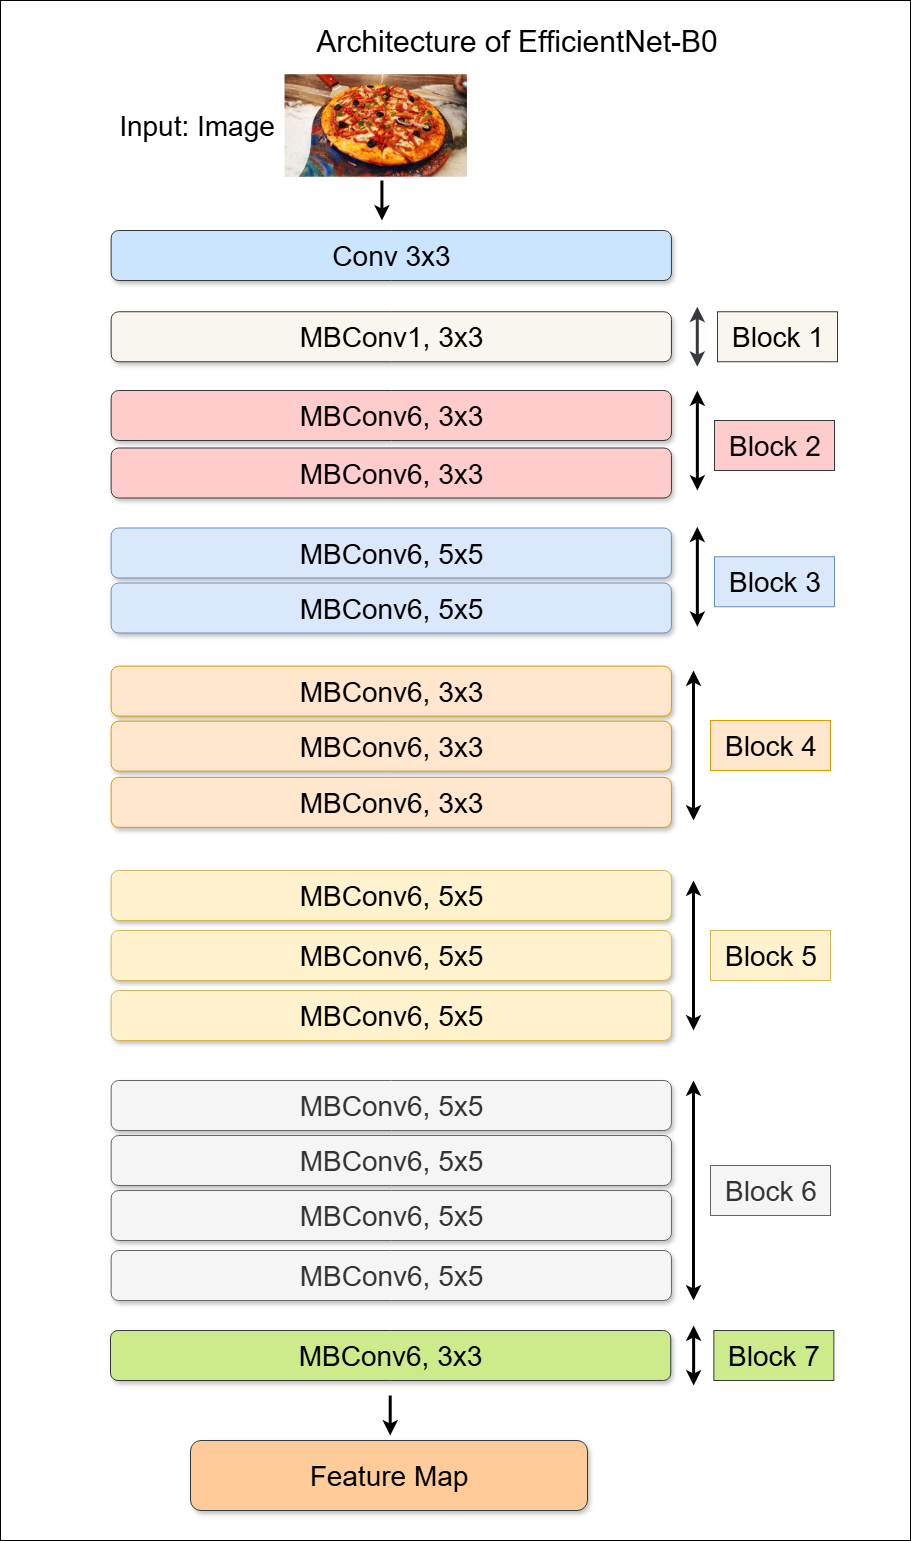
---
Looking at this diagram, you'll notice something different from the basic Conv2d layers we've used before. EfficientNet uses special building blocks called MBConv. Let's understand what these are.

## 🧱 Understanding MBConv Blocks

**MBConv (Mobile Inverted Bottleneck Convolution)** is the main building block used in EfficientNet.

👉 Think of it as a smarter version of regular convolution that achieves similar results with much less computation.

---

### 🔍 MBConv Variants in EfficientNet

In the architecture diagram, you may see labels like:

- MBConv1, 3x3  
- MBConv6, 5x5  

These have two important parts:

---

### 🔢 Expansion Factor (MBConv1 vs MBConv6)

- **MBConv1**
  - No channel expansion  
  - Keeps the same number of channels  

- **MBConv6**
  - Expands channels by **6× internally**  
  - Helps the model learn richer and more complex patterns  

---

### 📐 Kernel Size (3x3 vs 5x5)

- **3x3 filters**
  - Capture fine, local details 🔍  
- **5x5 filters**
  - Capture broader, more global patterns 🌐  

---
You don't need to understand the internal workings of MBConv to use transfer learning. Just know that these blocks are what make EfficientNet both accurate and efficient — they're the reason a small model like EfficientNet-B0 can match the accuracy of much larger models.


## 🧱 MBConv Blocks সহজভাবে বুঝি

EfficientNet-এর ভিতরের সবচেয়ে গুরুত্বপূর্ণ building block হলো **MBConv (Mobile Inverted Bottleneck Convolution)**।

👉 এটা এমন একটা smart convolution technique যা:

* কম computation ব্যবহার করে
* কিন্তু strong features শিখতে পারে

---

## 🔑 মূল আইডিয়া

👉 MBConv = **efficient + powerful block**

এটাই কারণ EfficientNet এত কম parameter দিয়েও ভালো performance দেয় (যেমন ImageNet-এ high accuracy)।

---

## 🔍 MBConv Variants বুঝি

Architecture-এ তুমি দেখবে:

* MBConv1, 3×3
* MBConv6, 5×5

এখানে দুইটা জিনিস গুরুত্বপূর্ণ 👇

---

## 🔢 1. Expansion Factor (MBConv1 vs MBConv6)

### 🔹 MBConv1

* Channels expand করে না
* Simple processing

👉 Lightweight, কম computation

---

### 🔹 MBConv6

* Channels **৬ গুণ বাড়ায় (expand করে)**
* তারপর processing করে

👉 কেন useful?

* বেশি channels → বেশি information process
* complex patterns শিখতে পারে

---

## 📐 2. Kernel Size (3×3 vs 5×5)

### 🔹 3×3 filter

* ছোট area দেখে
* fine details capture করে 🔍

---

### 🔹 5×5 filter

* বড় area cover করে
* broader patterns capture করে 🌐

---

## 🧠 Intuition

* Expansion (MBConv6) = “বেশি feature নিয়ে ভাবা”
* Kernel size বড় = “বড় area দেখে বোঝা”

👉 দুইটা combine হলে:

* local + global features দুটোই শেখা যায়

---

## 🔥 কেন MBConv এত important?

* কম parameter ব্যবহার করে
* efficient computation
* কিন্তু accuracy high রাখে

👉 এই কারণেই:
**EfficientNet-B0 ছোট হয়েও বড় model-এর মতো perform করতে পারে**



##**Our Problem: Food Classification**

Now that we understand transfer learning and EfficientNet architecture, let's apply this knowledge to our specific problem.

**The Dataset**

We'll use a simple food classification dataset with 3 classes:
The Dataset
We'll use a simple food classification dataset with 3 classes:

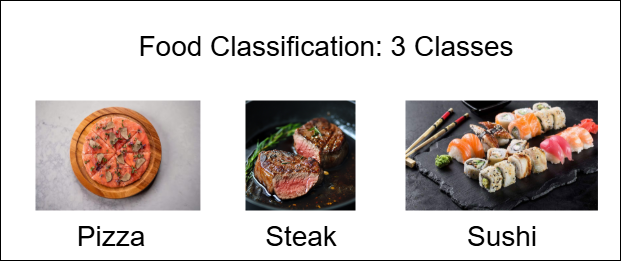



## 📊 Class Description

| Class | Description |
|------|-------------|
| Pizza | Images of various pizzas |
| Steak | Images of cooked steaks |
| Sushi | Images of sushi dishes |

---

## 📁 Dataset Structure

The dataset is organized in the standard image classification format:



data/pizza_steak_sushi/

├── train/

│   ├── pizza/    (75 images)

│   ├── steak/    (75 images)

│   └── sushi/    (75 images)

└── test/

├── pizza/    (25 images)

├── steak/    (25 images)

└── sushi/    (25 images)


---

This is a small dataset — only **225 training images** and **75 test images**.  

Training a model from scratch on such a small dataset would likely result in poor performance. This is exactly where transfer learning shines!



## 🧭 The Plan

We'll take the pretrained EfficientNet-B0 (trained on ImageNet's 1000 classes) and adapt it for our 3-class food classification:

- Freeze the feature extractor — Keep the learned patterns from ImageNet  
- Replace the classifier — Change from 1000 outputs to 3 outputs  
- Train only the classifier — In Lab 02, we'll train the new classifier on our food images  

## 🧭 The Plan — Step-by-Step বুঝি

আমরা একটা pretrained **EfficientNet-B0** (যেটা আগে ImageNet-এর 1000 classes শিখেছে) নিয়ে সেটাকে আমাদের **3-class food classification**-এর জন্য adapt করব।

---

## 🔹 Step 1: Freeze the Feature Extractor

👉 EfficientNet-এর **features অংশ (convolution layers)** freeze করে দিবো

মানে:

* এর weights change হবে না
* training-এর সময় update হবে না

📌 কেন?

* কারণ model already:

  * edges
  * textures
  * shapes
    শিখে ফেলেছে

👉 এই knowledge আমরা 그대로 রাখতে চাই

---

## 🔹 Step 2: Replace the Classifier

👉 Original classifier:

* 1000 classes (ImageNet)

👉 আমরা replace করে বানাবো:

* 3 classes → (pizza, steak, sushi)

📌 মানে:

* পুরানো head remove
* নতুন head add

---

## 🔹 Step 3: Train Only the Classifier

👉 এখন training করবো শুধু:

* নতুন classifier layer

👉 EfficientNet-এর বাকি অংশ untouched থাকবে

📌 কেন?

* কম data থাকলেও training stable হয়
* fast training হয়
* overfitting কম হয়


## 🔧 Adapting EfficientNet for Our Task

### Step 1: Freeze the Feature Extractor

The features section of EfficientNet has already learned powerful image representations from millions of ImageNet images. These learned patterns (edges, textures, shapes, objects) are useful for recognizing food too — we don't want to lose them.

By freezing these layers, we keep the pretrained weights fixed during training:

In [ ]:
# Freeze all layers in the features section
for param in model.features.parameters():
    param.requires_grad = False

1️⃣ `model.features.parameters()`

👉 এটা EfficientNet-এর features অংশের সব parameters (weights) access করছে

অর্থাৎ convolution layers (feature extractor)

3️⃣ `param.requires_grad = False`

👉 এটা সবচেয়ে গুরুত্বপূর্ণ 👇

requires_grad = False মানে:
এই parameter-এর gradient calculate হবে না
training-এর সময় update হবে না

When `requires_grad=False`, the layer won't be updated during training. This makes training much faster since we're not computing gradients for millions of parameters.

**Step 2: Replace the Classifier**

The original EfficientNet classifier outputs 1000 classes (for ImageNet). We need only 3 classes for our food problem:

In [ ]:
# Replace the classifier
model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True),
    nn.Linear(in_features=1280, out_features=3)  # 3 classes: pizza, steak, sushi
)


## 🔑 কী হচ্ছে এখানে?

👉 আমরা পুরানো classifier (1000 classes for ImageNet) remove করে
👉 নতুন classifier বসাচ্ছি (3 classes-এর জন্য)

---

## 🧱 Breakdown

### 1️⃣ `nn.Sequential(...)`

👉 এটা layer-গুলোকে sequence আকারে connect করে
মানে:

> Input → Dropout → Linear → Output

---

### 2️⃣ `nn.Dropout(p=0.2)`

👉 Dropout layer:

* Training-এর সময় 20% neuron randomly off করে
* Overfitting কমায়

📌 কেন দরকার?

* আমাদের dataset ছোট → overfitting হওয়ার chance বেশি

---

### 3️⃣ `nn.Linear(in_features=1280, out_features=3)`

👉 এটা final fully connected layer

* `in_features=1280`

  * EfficientNet-B0 feature extractor থেকে output size
* `out_features=3`

  * আমাদের classes: pizza, steak, sushi

📌 Result:

> Model এখন 3টা class-এর probability output দিবে



## 📈 The Result

After these modifications:

| Aspect | Before | After |
|--------|--------|-------|
| Feature layers | Trainable (5.3M params) | Frozen |
| Classifier output | 1000 classes | 3 classes |
| Trainable parameters | ~5,288,548 | ~3,843 |

We went from training 5.3 million parameters to just ~3,843! This means faster training, less memory usage, and less risk of overfitting on our small dataset.

# Preparing Data for Pretrained Models

**Why Data Preparation Matters**

The pretrained EfficientNet-B0 was trained on ImageNet images that were preprocessed in a specific way. For the model to work correctly on our food images, we need to preprocess them *exactly the same way.*

Think of it like this: if someone learned to recognize faces from black-and-white photos, showing them color photos might confuse them. Similarly, our pretrained model expects images in a specific format.

## 🔷 Why Data Preparation Matters

Pretrained EfficientNet-B0 যেটা **ImageNet** দিয়ে train করা হয়েছে, সেটার জন্য images একটি নির্দিষ্ট format-এ preprocess করা হয়েছিল।

👉 তাই inference বা fine-tuning করার সময় আমাদের নতুন images-ও **same way** preprocess করতে হয়।

---

## 🔑 মূল কারণ

👉 Model “যেভাবে দেখেছে”, সেভাবেই নতুন data দেখতে হবে
না হলে model confuse হয়ে যেতে পারে।

---

## 🧠 Intuition (সহজ উদাহরণ)

ধরো একজন মানুষ:

* সে শুধু **black & white photos** দেখে face চিনতে শিখেছে
* এখন তাকে suddenly **color photos** দেখানো হলো

👉 সে হয়তো:

* features mismatch পাবে
* confuse হয়ে যাবে
* accuracy কমে যাবে

---

## 🔁 Same applies to model

Pretrained model:

* specific **input size (224×224)**
* specific **normalization (mean/std)**
* specific **data distribution**



## 🧼 What Preprocessing Is Needed?

For EfficientNet-B0, each image must go through these steps:

| Step | What It Does | Why It's Needed |
|------|-------------|----------------|
| Resize | Scale image to 224×224 pixels | Model expects this exact input size |
| ToTensor | Convert image to PyTorch tensor, scale values to [0, 1] | Neural networks work with tensors, not image files |
| Normalize | Adjust values using ImageNet mean and std | Makes our data distribution match ImageNet's |

## 🧼 EfficientNet-B0-এর জন্য Preprocessing কী দরকার?

Pretrained EfficientNet-B0 ব্যবহার করার সময় প্রতিটি image-কে কিছু standard step দিয়ে process করতে হয়, যাতে model ঠিকভাবে বুঝতে পারে।

---

## 🔹 Step-by-Step Preprocessing

### 1️⃣ Resize → 224×224

👉 Model input size fixed: **224×224**

* যেকোন image থাকুক, সেটাকে resize করতে হবে
* না হলে model accept করবে না বা performance খারাপ হবে

📌 কারণ:

> EfficientNet-B0 (trained on ImageNet) expects this exact size

---

### 2️⃣ ToTensor → Image → Tensor

👉 Image file (JPG/PNG) কে convert করে:

* PyTorch tensor
* pixel values scale হয়: **0 → 1**

📌 কেন?

* Neural network শুধু numerical tensor নিয়ে কাজ করে
* raw image directly process করতে পারে না

---

### 3️⃣ Normalize → Standardize values

👉 Image pixel values adjust করা হয় using:

* mean
* standard deviation

📌 Why?

* Pretrained model যেই distribution-এ train হয়েছে, সেই distribution match করতে হয়
* না হলে performance degrade হতে পারে




# How to Apply These Transforms
PyTorch makes this easy — we can get the exact transforms from the pretrained weights:

In [ ]:
# Get pretrained weights
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT

# Get the transforms used to train those weights
auto_transforms = weights.transforms()

This `auto_transforms` will automatically

resize,

convert to tensor, and

normalize any image

we pass through it — exactly matching how ImageNet images were prepared during training.


## 🔑 কী হচ্ছে এখানে?

### 1️⃣ `EfficientNet_B0_Weights.DEFAULT`

👉 এটা pretrained weights load করছে

* এই weights already **ImageNet** dataset দিয়ে train করা

📌 `DEFAULT` মানে:

> official recommended pretrained weights

---

### 2️⃣ `weights.transforms()`

👉 এটা automatically সেই preprocessing pipeline দেয় যেটা training time-এ ব্যবহার করা হয়েছিল

এর মধ্যে include থাকে:

* Resize (224×224)
* CenterCrop
* ToTensor
* Normalize (ImageNet mean/std)

📌 মানে:

> তোমাকে manually transforms লিখতে হচ্ছে না





Setting Up the Environment

Now we'll set up the environment and run the notebook to explore the pretrained model.

Step 1: Install Jupyter Extension

Open VS Code Server provided by Poridhi, go to Extensions (Ctrl+Shift+X), and install the Jupyter extension.

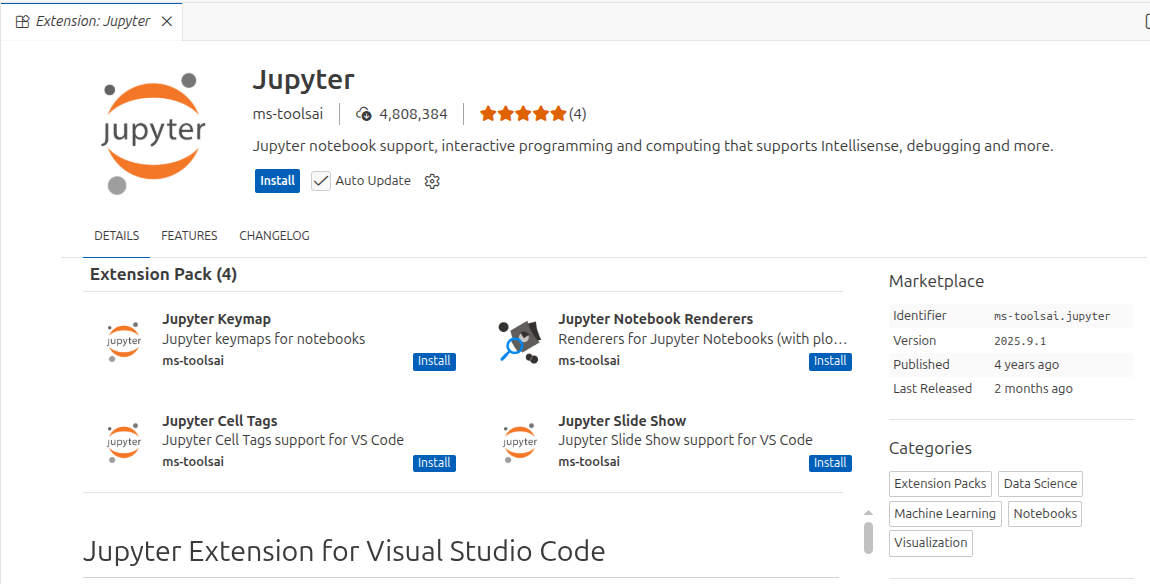

Step 2: Create Virtual Environment

In [ ]:
sudo apt update
sudo apt install python3.12-venv
python3 -m venv venv
source venv/bin/activate


Step 3: Download the Notebook

In [1]:
!curl -O https://raw.githubusercontent.com/poridhioss/Introduction-to-Deep-Learning-with-Pytorch-Resources/refs/heads/main/Transfer-learning/Lab_01/lab_01.ipynb


  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 26210  100 26210    0     0   120k      0 --:--:-- --:--:-- --:--:--  120k


It will download the notebook to your current directory.

**Next Steps**

Open lab_01.ipynb in VS Code. In top right corner of the notebook you will see a button select kernel. Click on it, then a pop up will open to select python environment. After selecting python environment for first time it will ask permission to install python ipykernel. Click on install button to install the python ipykernel. Once installed, you will see the venv virtual environment in the list of kernels. Select it as the kernel.

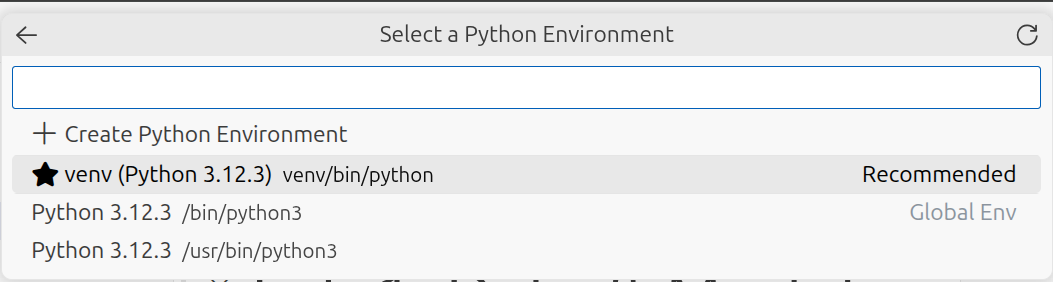